In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8-darkgrid')

Shape: (1075, 11)
Date range: 2023-01-12 to 2025-12-21


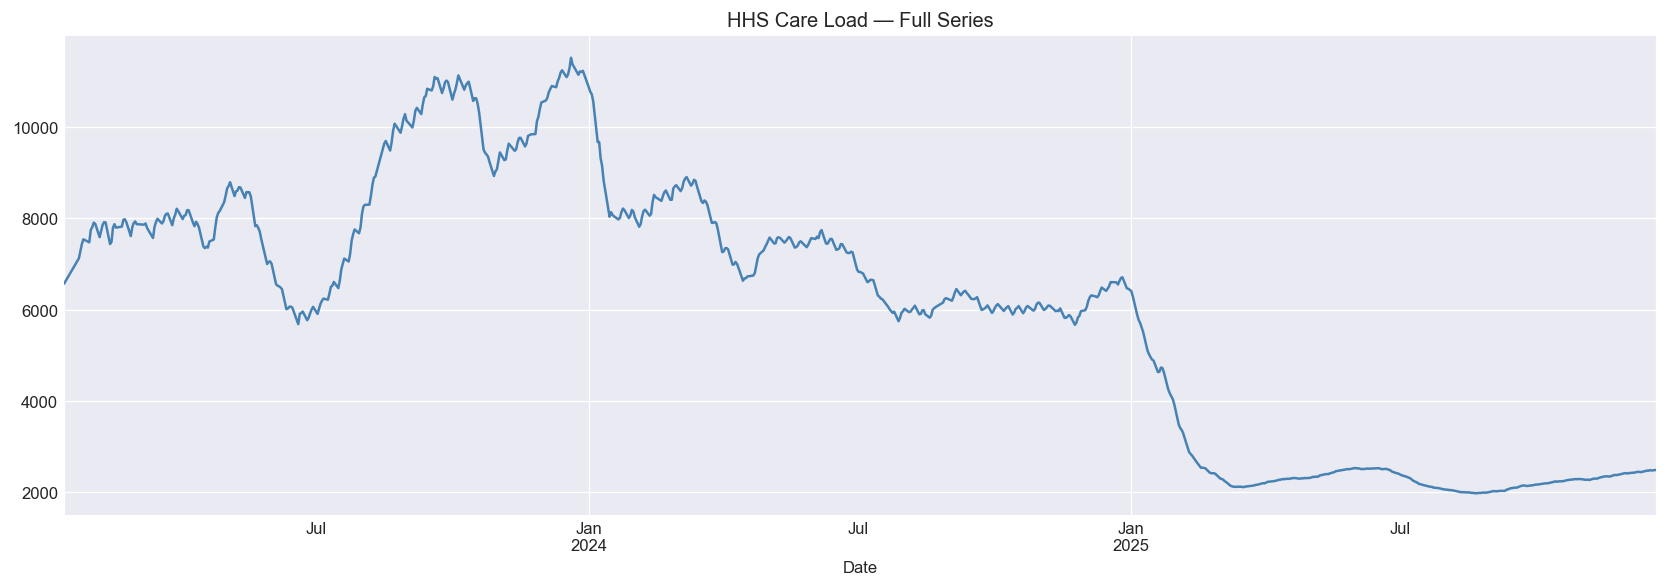

In [4]:
data = pd.read_csv('../data/processed/cleaned_data.csv', 
                 index_col='Date', parse_dates=True)

df = data.copy()

print("Shape:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
df['hhs_care'].plot(title='HHS Care Load — Full Series', 
                    color='steelblue', linewidth=1.5)
plt.tight_layout()
plt.show()

Total rows   : 1075
Train rows   : 967 (90.0%)
Test rows    : 108  (10.0%)
Train period : 2023-01-12 to 2025-09-04
Test period  : 2025-09-05 to 2025-12-21


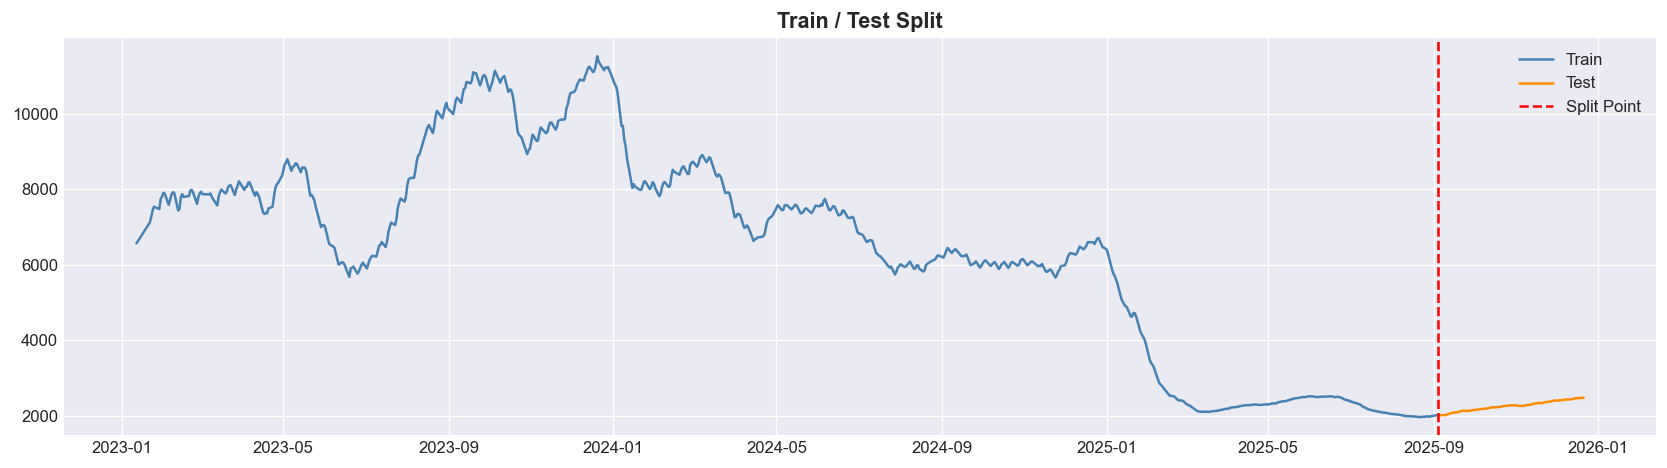

In [5]:
# 80% train, 20% test — strict time based split
split_index = int(len(df) * 0.90)

train = df.iloc[:split_index]['hhs_care']
test  = df.iloc[split_index:]['hhs_care']

print(f"Total rows   : {len(df)}")
print(f"Train rows   : {len(train)} ({len(train)/len(df)*100:.1f}%)")
print(f"Test rows    : {len(test)}  ({len(test)/len(df)*100:.1f}%)")
print(f"Train period : {train.index.min().date()} to {train.index.max().date()}")
print(f"Test period  : {test.index.min().date()} to {test.index.max().date()}")

# Visualise the split
plt.figure(figsize=(14, 4))
plt.plot(train.index, train.values, color='steelblue', 
         linewidth=1.5, label='Train')
plt.plot(test.index,  test.values,  color='darkorange', 
         linewidth=1.5, label='Test')
plt.axvline(x=train.index[-1], color='red', 
            linestyle='--', linewidth=1.5, label='Split Point')
plt.title('Train / Test Split', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()


plt.savefig('../reports/figures/train_test_split.png', bbox_inches='tight')
plt.show()

In [6]:
# Evaluation Metrics 

def evaluate_forecast(actual, predicted, model_name):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    
    mae  = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-10))) * 100
    
    print(f"\n{'='*45}")
    print(f"  Model : {model_name}")
    print(f"{'='*45}")
    print(f"  MAE   : {mae:.2f}")
    print(f"  RMSE  : {rmse:.2f}")
    print(f"  MAPE  : {mape:.2f}%")
    print(f"{'='*45}")
    
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


  Model : Naive Persistence
  MAE   : 6.06
  RMSE  : 7.24
  MAPE  : 0.27%


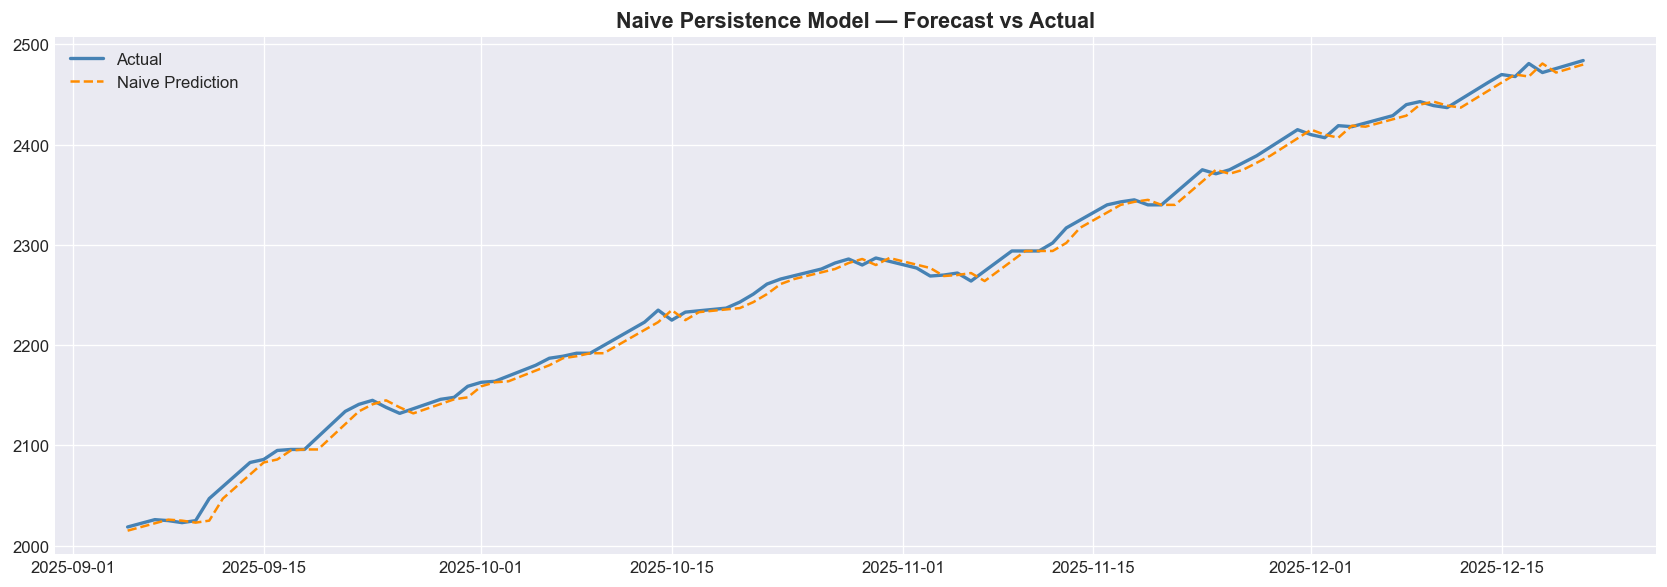

In [7]:
# Naive Persistence Model

# Naive model — predict tomorrow = today
naive_predictions = test.shift(1).fillna(train.iloc[-1])

naive_results = evaluate_forecast(test, naive_predictions, 'Naive Persistence')

# Plot
plt.figure(figsize=(14, 5))
plt.plot(test.index,  test.values,             color='steelblue',  
         linewidth=2,   label='Actual')
plt.plot(test.index,  naive_predictions.values, color='darkorange', 
         linewidth=1.5, label='Naive Prediction', linestyle='--')
plt.title('Naive Persistence Model — Forecast vs Actual', 
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/naive_forecast.png', bbox_inches='tight')
plt.show()


  Model : Moving Average (window=3)
  MAE   : 9.76
  RMSE  : 11.77
  MAPE  : 0.43%


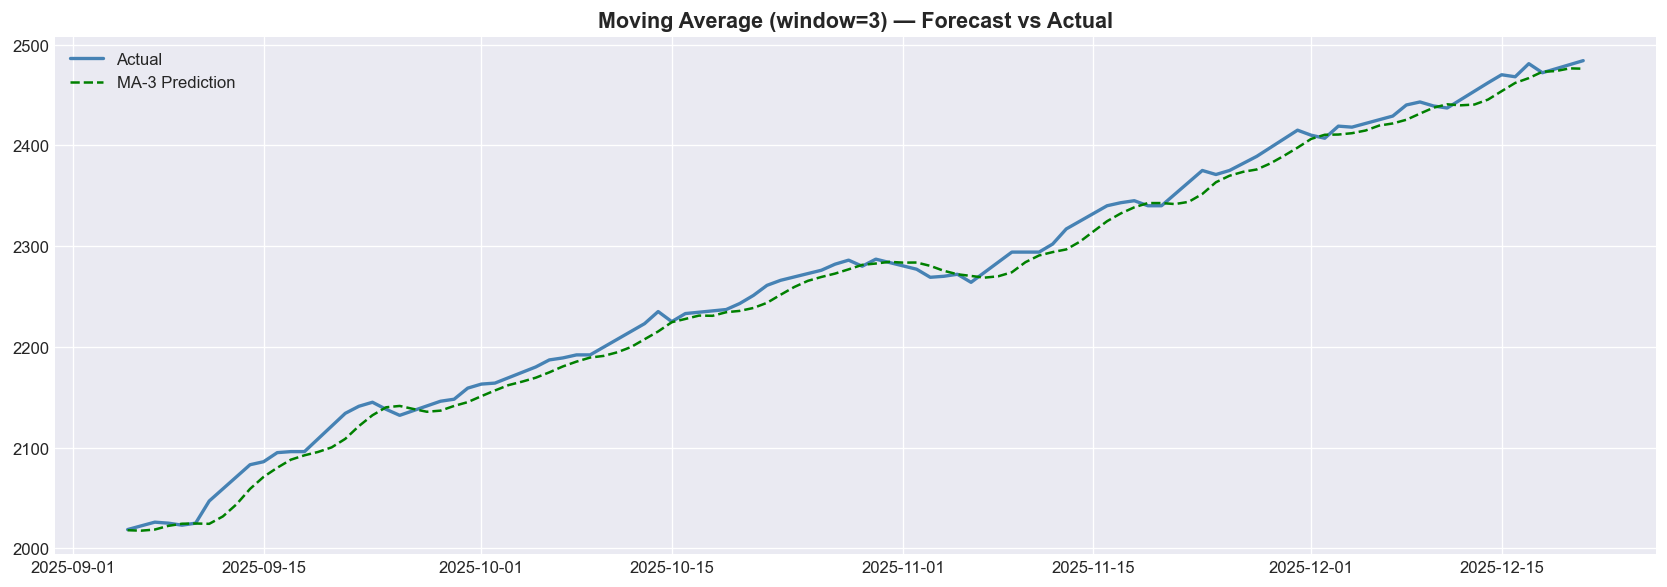

In [8]:
# Moving Average Model

# Moving average model — predict using rolling mean of last N days
ma_window = 3

# Calculate rolling mean on training data
# For test period we use expanding window from end of training
ma_predictions = []

for i in range(len(test)):
    if i < ma_window:
        # Use last ma_window values from training + previous test predictions
        history = list(train.values[-ma_window+i:]) + \
                  list(test.values[:i])
    else:
        history = list(test.values[i-ma_window:i])
    
    ma_predictions.append(np.mean(history))

ma_predictions = pd.Series(ma_predictions, index=test.index)

ma_results = evaluate_forecast(test, ma_predictions, f'Moving Average (window={ma_window})')

# Plot
plt.figure(figsize=(14, 5))
plt.plot(test.index, test.values,          color='steelblue',  
         linewidth=2,   label='Actual')
plt.plot(test.index, ma_predictions.values, color='green',      
         linewidth=1.5, label=f'MA-{ma_window} Prediction', linestyle='--')
plt.title(f'Moving Average (window={ma_window}) — Forecast vs Actual', 
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/ma_forecast.png', bbox_inches='tight')
plt.show()


  Model : MA-3
  MAE   : 9.76
  RMSE  : 11.77
  MAPE  : 0.43%

  Model : MA-7
  MAE   : 18.14
  RMSE  : 20.33
  MAPE  : 0.80%

  Model : MA-14
  MAE   : 32.88
  RMSE  : 35.27
  MAPE  : 1.46%

  Model : MA-30
  MAE   : 64.98
  RMSE  : 67.64
  MAPE  : 2.87%


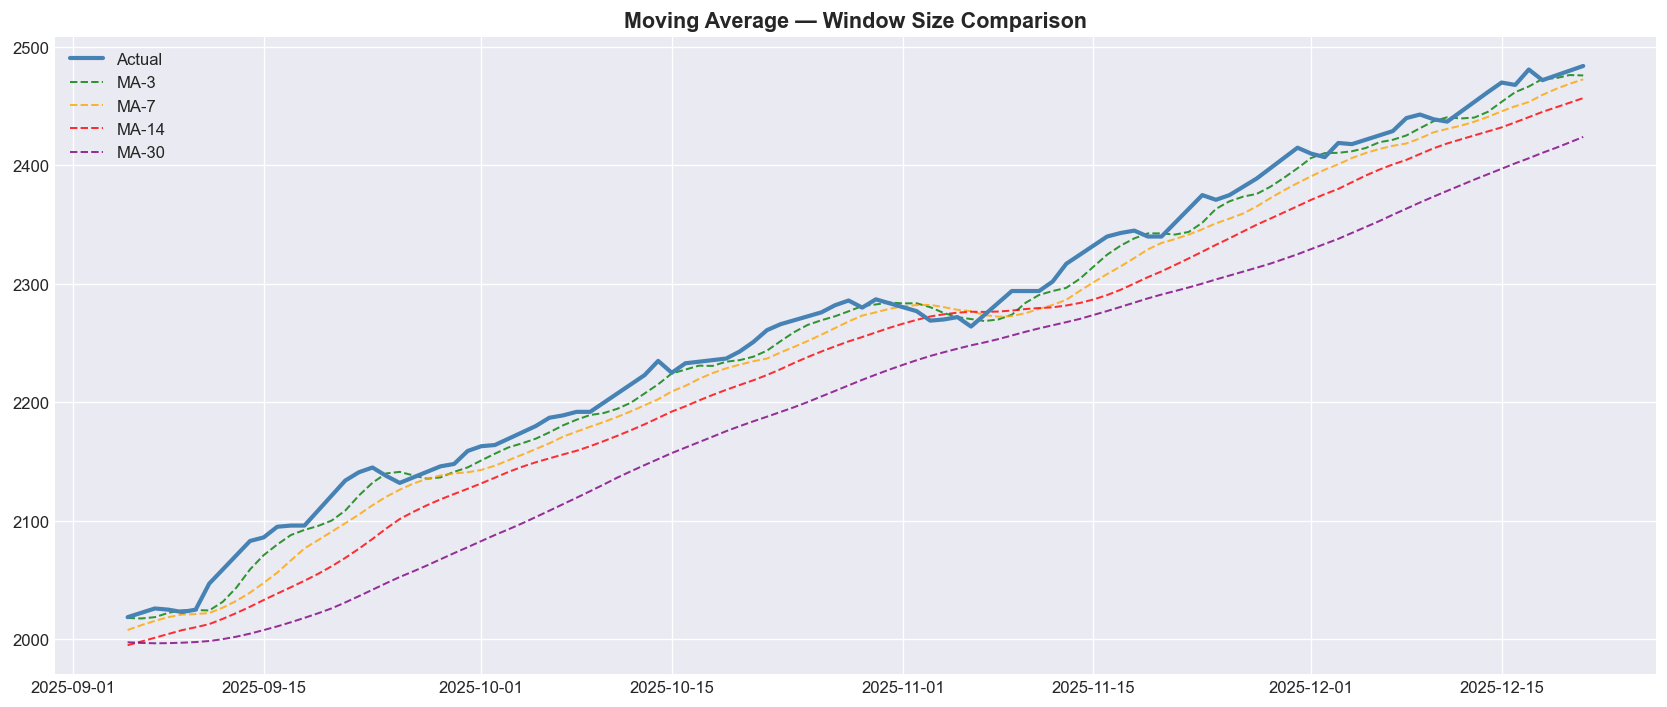

In [9]:
# Moving Average Window Comparison

# Compare different window sizes
windows_to_try = [3, 7, 14, 30]
window_results = []

plt.figure(figsize=(14, 6))
plt.plot(test.index, test.values, color='steelblue', 
         linewidth=2.5, label='Actual', zorder=5)

colors = ['green', 'orange', 'red', 'purple']

for window, color in zip(windows_to_try, colors):
    preds = []
    for i in range(len(test)):
        if i < window:
            history = list(train.values[-window+i:]) + list(test.values[:i])
        else:
            history = list(test.values[i-window:i])
        preds.append(np.mean(history))
    
    preds_series = pd.Series(preds, index=test.index)
    results = evaluate_forecast(test, preds_series, f'MA-{window}')
    window_results.append(results)
    
    plt.plot(test.index, preds_series.values, color=color,
             linewidth=1.2, linestyle='--', label=f'MA-{window}', alpha=0.8)

plt.title('Moving Average — Window Size Comparison', 
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/ma_window_comparison.png', bbox_inches='tight')
plt.show()

Baseline Model Comparison:
                            MAE   RMSE  MAPE
Model                                       
Naive Persistence          6.06   7.24  0.27
Moving Average (window=3)  9.76  11.77  0.43


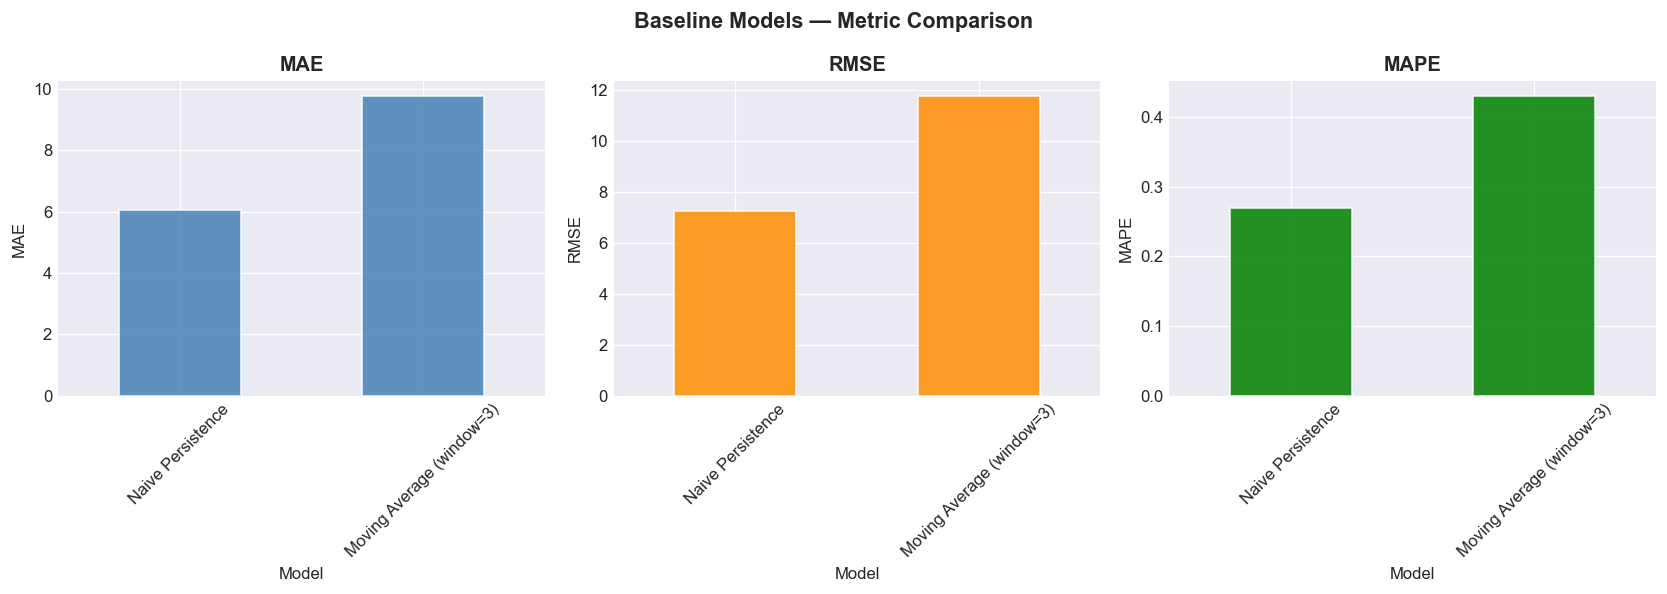

In [10]:
all_baseline_results = [naive_results, ma_results]

results_df = pd.DataFrame(all_baseline_results)
results_df = results_df.set_index('Model')
results_df = results_df.round(2)

print("Baseline Model Comparison:")
print(results_df)

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'RMSE', 'MAPE']
colors  = ['steelblue', 'darkorange', 'green']

for ax, metric, color in zip(axes, metrics, colors):
    results_df[metric].plot(kind='bar', ax=ax, color=color, 
                            edgecolor='white', alpha=0.85)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Baseline Models — Metric Comparison', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/baseline_comparison.png', bbox_inches='tight')
plt.show()

In [11]:
results_df.to_csv('../models/baseline_results.csv')
print("Baseline results saved.")
print()
print("Key Findings:")
print(f"  Best MAE  : {results_df['MAE'].min():.2f}  ({results_df['MAE'].idxmin()})")
print(f"  Best RMSE : {results_df['RMSE'].min():.2f} ({results_df['RMSE'].idxmin()})")
print(f"  Best MAPE : {results_df['MAPE'].min():.2f}% ({results_df['MAPE'].idxmin()})")
print()
print("These results set the performance floor.")
print("All subsequent models must beat these numbers.")

Baseline results saved.

Key Findings:
  Best MAE  : 6.06  (Naive Persistence)
  Best RMSE : 7.24 (Naive Persistence)
  Best MAPE : 0.27% (Naive Persistence)

These results set the performance floor.
All subsequent models must beat these numbers.
